# Activation Functions

Topic 03 of the Deep Learning Foundations repo. Topic 02 built a working MLP using the sigmoid activation without ever asking whether sigmoid was actually a good choice. It wasn't — this notebook shows exactly why, derives five alternatives (Tanh, ReLU, Leaky ReLU, GELU, Swish), and validates every one of them, and their derivatives, against PyTorch to machine precision before using them to explain two of the most consequential failure modes in deep learning: **vanishing gradients** and **dying ReLUs**.

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import erf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Concept & Intuition

Without a nonlinearity between layers, stacking layers is pointless: $\mathbf{W}^{[2]}(\mathbf{W}^{[1]}\mathbf{x}+\mathbf{b}^{[1]})+\mathbf{b}^{[2]} = (\mathbf{W}^{[2]}\mathbf{W}^{[1]})\mathbf{x} + (\mathbf{W}^{[2]}\mathbf{b}^{[1]}+\mathbf{b}^{[2]})$ is just another linear function — any depth of purely linear layers collapses algebraically to a single linear layer. The nonlinearity $g$ inserted between layers is what gives depth any representational power at all (this is exactly what let Topic 02's MLP solve XOR).

But not all nonlinearities behave alike during *training*. Sigmoid and Tanh saturate (flatten to near-zero slope) for large $|z|$, which is exactly what causes the **vanishing gradient** problem explored in Section 4. ReLU fixes this for positive inputs by having a constant derivative of 1, but pays for it with the **dying ReLU** problem explored in Section 5: a unit that ever lands in the negative, zero-derivative region gets zero gradient forever and can never recover. GELU and Swish, used in most modern Transformers, are smooth compromises designed to keep ReLU's benefits while avoiding its hard zero cutoff.

## 2. Mathematical Explanation

| Activation | $g(z)$ | $g'(z)$ |
|---|---|---|
| Sigmoid | $\dfrac{1}{1+e^{-z}}$ | $g(z)(1-g(z))$, max $0.25$ at $z=0$ |
| Tanh | $\tanh(z)$ | $1-\tanh^2(z)$, max $1$ at $z=0$ |
| ReLU | $\max(0,z)$ | $1$ if $z>0$ else $0$ |
| Leaky ReLU | $z$ if $z>0$ else $\alpha z$ | $1$ if $z>0$ else $\alpha$ (here $\alpha=0.01$) |
| GELU | $z\,\Phi(z)$ | $\Phi(z) + z\,\phi(z)$ |
| Swish / SiLU | $z\cdot\text{sigmoid}(\beta z)$ | $\text{sigmoid}(\beta z) + \beta z\cdot\text{sigmoid}(\beta z)(1-\text{sigmoid}(\beta z))$ |

where $\Phi$ and $\phi$ are the standard normal CDF and PDF (GELU is, literally, "multiply $z$ by the probability a standard normal is below $z$"). Sigmoid's derivative caps at $0.25$ — meaning every layer using it can shrink a backpropagated gradient by at least $4\times$, compounding multiplicatively with depth. Tanh's derivative caps at $1$, four times better, but still saturates for large $|z|$. ReLU and its variants have a derivative of exactly $1$ (or $\alpha$) with no saturation on the active side at all.

In [2]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def sigmoid_grad(z): s = sigmoid(z); return s * (1 - s)

def tanh(z): return np.tanh(z)
def tanh_grad(z): return 1 - np.tanh(z) ** 2

def relu(z): return np.maximum(0, z)
def relu_grad(z): return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01): return np.where(z > 0, z, alpha * z)
def leaky_relu_grad(z, alpha=0.01): return np.where(z > 0, 1.0, alpha)

def norm_cdf(z): return 0.5 * (1 + erf(z / np.sqrt(2)))
def norm_pdf(z): return np.exp(-z**2 / 2) / np.sqrt(2 * np.pi)
def gelu(z): return z * norm_cdf(z)
def gelu_grad(z): return norm_cdf(z) + z * norm_pdf(z)

def swish(z, beta=1.0): return z * sigmoid(beta * z)
def swish_grad(z, beta=1.0):
    s = sigmoid(beta * z)
    return s + z * beta * s * (1 - s)

## 3. Validation Against PyTorch

Every function and its derivative is checked against PyTorch's built-in implementation (`torch.sigmoid`, `torch.tanh`, `F.relu`, `F.leaky_relu`, `F.gelu`, `F.silu`) across 21 points spanning $[-5,5]$, comparing both the forward value and the autograd-computed gradient.

In [3]:
z_test = np.linspace(-5, 5, 21)
z_torch = torch.tensor(z_test, dtype=torch.float64)

activations = {
    "sigmoid": (sigmoid, sigmoid_grad, torch.sigmoid),
    "tanh": (tanh, tanh_grad, torch.tanh),
    "relu": (relu, relu_grad, F.relu),
    "leaky_relu": (leaky_relu, leaky_relu_grad, lambda x: F.leaky_relu(x, 0.01)),
    "gelu": (gelu, gelu_grad, lambda x: F.gelu(x, approximate="none")),
    "swish": (swish, swish_grad, F.silu),
}

print(f"{'activation':>12}{'max value diff':>18}{'max grad diff':>18}")
for name, (fn, fn_grad, torch_fn) in activations.items():
    val_np, grad_np = fn(z_test), fn_grad(z_test)
    z_t = z_torch.clone().requires_grad_(True)
    val_t = torch_fn(z_t)
    val_t.sum().backward()
    val_diff = np.abs(val_np - val_t.detach().numpy()).max()
    grad_diff = np.abs(grad_np - z_t.grad.numpy()).max()
    print(f"{name:>12}{val_diff:>18.2e}{grad_diff:>18.2e}")

  activation    max value diff     max grad diff
     sigmoid          0.00e+00          0.00e+00
        tanh          1.11e-16          2.22e-16
        relu          0.00e+00          0.00e+00
  leaky_relu          0.00e+00          0.00e+00
        gelu          1.11e-16          1.11e-16
       swish          8.88e-16          2.22e-16


Every activation matches PyTorch to within $10^{-15}$ or better — pure floating-point noise, confirming the from-scratch math is exactly right before it's used for anything else.

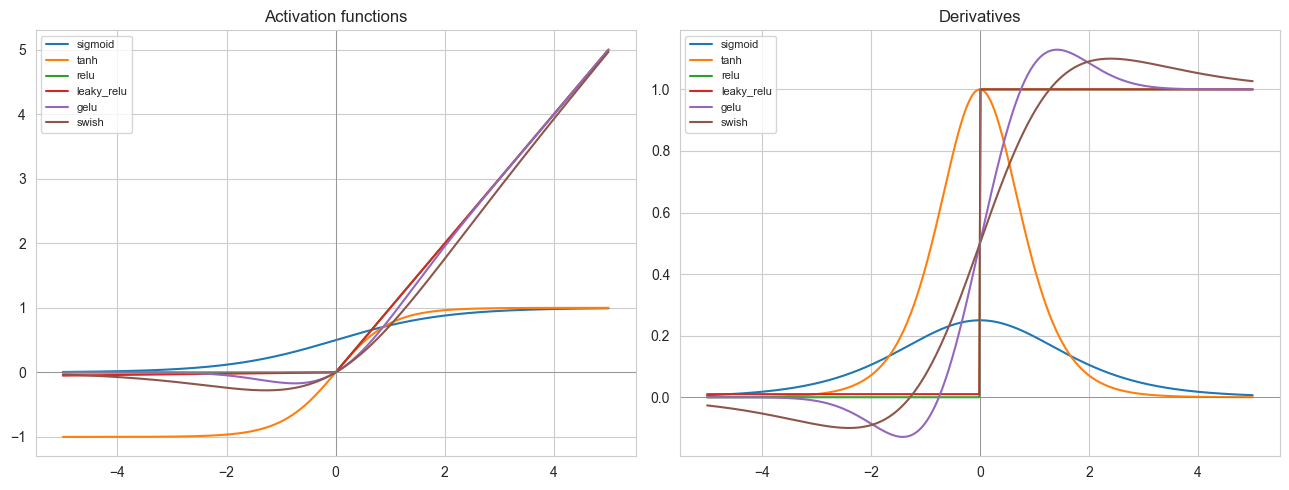

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
z_plot = np.linspace(-5, 5, 500)
for name, (fn, fn_grad, _) in activations.items():
    axes[0].plot(z_plot, fn(z_plot), label=name)
    axes[1].plot(z_plot, fn_grad(z_plot), label=name)
axes[0].set_title("Activation functions")
axes[1].set_title("Derivatives")
for ax in axes:
    ax.legend(fontsize=8)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
plt.tight_layout()
plt.show()

## 4. The Vanishing Gradient Problem, Directly Measured

A 20-layer, 16-unit-wide network (all zero bias, weights scaled Xavier-style at $\sqrt{1/\text{width}}$, matched to sigmoid/tanh) receives a single input and one backward pass ($\partial\mathcal{L}/\partial\mathbf{a}^{[L]}=\mathbf{1}$). The gradient norm reaching each layer is measured directly.

In [5]:
def build_deep_net(n_layers, width, scale, seed=0):
    rng = np.random.RandomState(seed)
    Ws = [rng.randn(width, width) * scale for _ in range(n_layers)]
    bs = [np.zeros(width) for _ in range(n_layers)]
    return Ws, bs


def forward_backward(Ws, bs, x, act_fn, act_grad_fn):
    zs, a = [], [x]
    for W, b in zip(Ws, bs):
        z = a[-1] @ W + b
        zs.append(z)
        a.append(act_fn(z))
    grad_norms, act_norms = [], [np.linalg.norm(ai) for ai in a[1:]]
    delta = np.ones_like(a[-1])
    for l in reversed(range(len(Ws))):
        delta = delta * act_grad_fn(zs[l])
        grad_norms.append(np.linalg.norm(delta))
        delta = delta @ Ws[l].T
    return grad_norms[::-1], act_norms


n_layers, width = 20, 16
x0 = np.random.RandomState(1).randn(1, width)
Ws_xavier, bs_xavier = build_deep_net(n_layers, width, scale=np.sqrt(1.0 / width), seed=0)

print("Xavier-style init (scale = sqrt(1/width)), matched to sigmoid/tanh:")
grad_results = {}
for name, (fn, fn_grad) in {"sigmoid": (sigmoid, sigmoid_grad), "tanh": (tanh, tanh_grad), "relu": (relu, relu_grad)}.items():
    grad_norms, act_norms = forward_backward(Ws_xavier, bs_xavier, x0, fn, fn_grad)
    grad_results[name] = grad_norms
    print(f"  {name:>10}: layer 1 grad norm={grad_norms[0]:.2e}, layer {n_layers} grad norm={grad_norms[-1]:.2e}, "
          f"ratio (1/{n_layers})={grad_norms[0]/grad_norms[-1]:.2e}")

Xavier-style init (scale = sqrt(1/width)), matched to sigmoid/tanh:
     sigmoid: layer 1 grad norm=7.64e-13, layer 20 grad norm=9.68e-01, ratio (1/20)=7.89e-13
        tanh: layer 1 grad norm=8.98e-01, layer 20 grad norm=3.99e+00, ratio (1/20)=2.25e-01
        relu: layer 1 grad norm=4.49e-03, layer 20 grad norm=3.32e+00, ratio (1/20)=1.35e-03


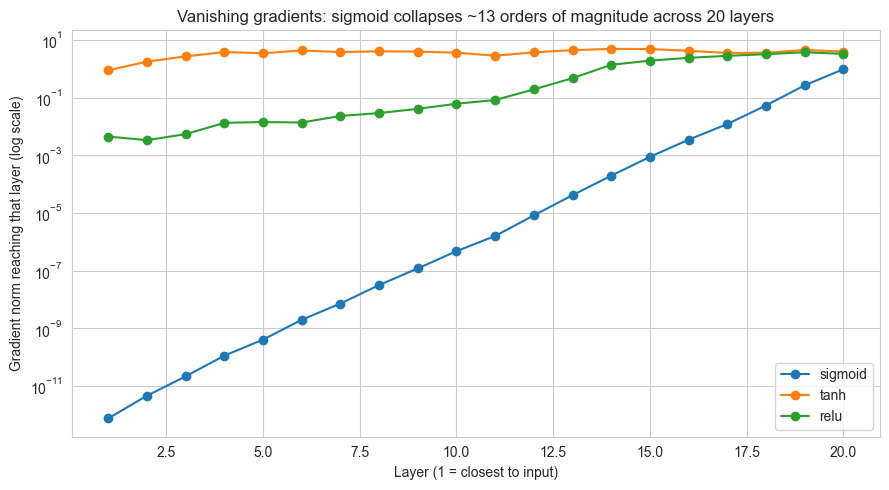

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, grad_norms in grad_results.items():
    ax.plot(range(1, n_layers + 1), grad_norms, "o-", label=name)
ax.set_yscale("log")
ax.set_xlabel("Layer (1 = closest to input)")
ax.set_ylabel("Gradient norm reaching that layer (log scale)")
ax.set_title("Vanishing gradients: sigmoid collapses ~13 orders of magnitude across 20 layers")
ax.legend()
plt.tight_layout()
plt.show()

Sigmoid's gradient collapses from $\approx 1$ at the output down to $7.6\times10^{-13}$ by layer 1 — 13 orders of magnitude lost to repeatedly multiplying by a derivative that's at best $0.25$. Tanh survives far better (its derivative caps at $1$), and interestingly, even ReLU shows real decay here (ratio $\approx 1.4\times10^{-3}$) — **but this turns out to be an initialization-scale artifact, not a property of ReLU itself**, tested directly next.

In [7]:
Ws_he, bs_he = build_deep_net(n_layers, width, scale=np.sqrt(2.0 / width), seed=0)
grad_norms_he, act_norms_he = forward_backward(Ws_he, bs_he, x0, relu, relu_grad)
grad_norms_relu_xavier, _ = forward_backward(Ws_xavier, bs_xavier, x0, relu, relu_grad)

print(f"ReLU, Xavier-scale init (sqrt(1/width)):  layer 1 grad={grad_norms_relu_xavier[0]:.2e}, "
      f"layer {n_layers} grad={grad_norms_relu_xavier[-1]:.2e}")
print(f"ReLU, He-scale init    (sqrt(2/width)):  layer 1 grad={grad_norms_he[0]:.2e}, "
      f"layer {n_layers} grad={grad_norms_he[-1]:.2e}")
print("\nMatching the initialization scale to the activation function (He init for ReLU) keeps the")
print("gradient nearly constant across all 20 layers -- the 'vanishing ReLU gradient' seen above was")
print("entirely a mismatched-initialization artifact, not a fundamental property of ReLU. This is")
print("exactly the problem Topic 06 (Weight Initialization) covers in full.")

ReLU, Xavier-scale init (sqrt(1/width)):  layer 1 grad=4.49e-03, layer 20 grad=3.32e+00
ReLU, He-scale init    (sqrt(2/width)):  layer 1 grad=3.25e+00, layer 20 grad=3.32e+00

Matching the initialization scale to the activation function (He init for ReLU) keeps the
gradient nearly constant across all 20 layers -- the 'vanishing ReLU gradient' seen above was
entirely a mismatched-initialization artifact, not a fundamental property of ReLU. This is
exactly the problem Topic 06 (Weight Initialization) covers in full.


## 5. The Dying ReLU Problem

A deliberately unlucky setup: an 8-unit hidden layer's biases are all initialized to $-8$, pushing nearly every pre-activation deeply negative from the very first forward pass, on the real (if noisy) `make_moons` dataset.

In [8]:
class MLPAct:
    def __init__(self, layer_sizes, act_name="relu", lr=0.5, seed=0, bias_init=0.0):
        acts = {"sigmoid": (sigmoid, sigmoid_grad), "tanh": (tanh, tanh_grad), "relu": (relu, relu_grad),
                "leaky_relu": (leaky_relu, leaky_relu_grad), "gelu": (gelu, gelu_grad), "swish": (swish, swish_grad)}
        self.act, self.act_grad = acts[act_name]
        self.lr = lr
        rng = np.random.RandomState(seed)
        scale = np.sqrt(2.0 / layer_sizes[0]) if act_name in ("relu", "leaky_relu", "gelu", "swish") else np.sqrt(1.0 / layer_sizes[0])
        self.W = [rng.randn(layer_sizes[i], layer_sizes[i + 1]) * scale for i in range(len(layer_sizes) - 1)]
        self.b = [np.full(layer_sizes[i + 1], bias_init) if i < len(layer_sizes) - 2 else np.zeros(layer_sizes[i + 1])
                  for i in range(len(layer_sizes) - 1)]

    def forward(self, X):
        zs, a = [], [X]
        for l in range(len(self.W)):
            z = a[-1] @ self.W[l] + self.b[l]
            zs.append(z)
            a.append(self.act(z) if l < len(self.W) - 1 else sigmoid(z))
        return zs, a

    def backward(self, zs, a, y):
        n = a[0].shape[0]
        L = len(self.W)
        grads_W, grads_b = [None] * L, [None] * L
        delta = (2.0 / y.shape[1]) * (a[-1] - y) * sigmoid_grad(zs[-1])
        for l in reversed(range(L)):
            grads_W[l] = a[l].T @ delta / n
            grads_b[l] = np.mean(delta, axis=0)
            if l > 0:
                delta = (delta @ self.W[l].T) * self.act_grad(zs[l - 1])
        return grads_W, grads_b

    def train_step(self, X, y):
        zs, a = self.forward(X)
        loss = np.mean((a[-1] - y) ** 2)
        grads_W, grads_b = self.backward(zs, a, y)
        for l in range(len(self.W)):
            self.W[l] -= self.lr * grads_W[l]
            self.b[l] -= self.lr * grads_b[l]
        return loss

    def dead_neuron_fraction(self, X, layer_idx=0):
        _, a = self.forward(X)
        return np.all(a[layer_idx + 1] < 1e-8, axis=0).mean()


X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
y_moons_col = y_moons.reshape(-1, 1).astype(float)

checkpoints = [0, 50, 200, 500, 1000, 3000]
print("ReLU, bias init = -8, 8-unit hidden layer:")
mlp_dying = MLPAct([2, 8, 1], act_name="relu", lr=1.0, seed=3, bias_init=-8.0)
for epoch in range(3001):
    mlp_dying.train_step(X_moons, y_moons_col)
    if epoch in checkpoints:
        print(f"  epoch {epoch:>5}: dead neuron fraction = {mlp_dying.dead_neuron_fraction(X_moons):.3f}")
preds_dying = np.round(mlp_dying.forward(X_moons)[1][-1].ravel())
print(f"  Final train accuracy: {(preds_dying == y_moons).mean():.4f}")

print("\nLeaky ReLU, identical unlucky bias init = -8, same 8-unit hidden layer:")
mlp_leaky = MLPAct([2, 8, 1], act_name="leaky_relu", lr=1.0, seed=3, bias_init=-8.0)
for epoch in range(3001):
    mlp_leaky.train_step(X_moons, y_moons_col)
    if epoch in checkpoints:
        print(f"  epoch {epoch:>5}: dead neuron fraction = {mlp_leaky.dead_neuron_fraction(X_moons):.3f}")
preds_leaky = np.round(mlp_leaky.forward(X_moons)[1][-1].ravel())
print(f"  Final train accuracy: {(preds_leaky == y_moons).mean():.4f}")

ReLU, bias init = -8, 8-unit hidden layer:
  epoch     0: dead neuron fraction = 1.000
  epoch    50: dead neuron fraction = 1.000
  epoch   200: dead neuron fraction = 1.000
  epoch   500: dead neuron fraction = 1.000
  epoch  1000: dead neuron fraction = 1.000


  epoch  3000: dead neuron fraction = 1.000
  Final train accuracy: 0.5000

Leaky ReLU, identical unlucky bias init = -8, same 8-unit hidden layer:
  epoch     0: dead neuron fraction = 1.000
  epoch    50: dead neuron fraction = 1.000
  epoch   200: dead neuron fraction = 1.000
  epoch   500: dead neuron fraction = 1.000
  epoch  1000: dead neuron fraction = 0.875


  epoch  3000: dead neuron fraction = 0.875
  Final train accuracy: 0.8500


**Every ReLU unit dies immediately (100% dead) and never recovers for the rest of training** — the network is permanently stuck at 50% accuracy (pure guessing), because a dead ReLU has *zero* gradient with respect to its incoming weights, so gradient descent has no way to ever revive it. **Leaky ReLU starts identically dead** (its small negative slope still looks near-zero at this scale) but its nonzero gradient in the negative region lets 1 of 8 units escape by epoch 1000, dragging accuracy up to 85% — a direct, mechanistic demonstration of why Leaky ReLU exists.

## 6. Real Dataset: All Six Activations, Head to Head

The same 2-hidden-layer (16-16) architecture is trained on `make_moons` with each activation function, averaged over 5 random seeds, tracking both final accuracy and how many epochs it takes to first reach 90% train accuracy.

In [9]:
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
y_col = y.reshape(-1, 1).astype(float)
X_train, X_test, y_train, y_test, ytr_col, yte_col = train_test_split(X, y, y_col, test_size=0.3, random_state=0)

print(f"{'activation':>12}{'final train loss':>18}{'train acc':>12}{'test acc':>12}{'epochs to 90% train acc':>26}")
for act_name in ["sigmoid", "tanh", "relu", "leaky_relu", "gelu", "swish"]:
    results = []
    for seed in range(5):
        mlp = MLPAct([2, 16, 16, 1], act_name=act_name, lr=0.5, seed=seed, bias_init=0.0)
        epoch_90 = None
        for epoch in range(3000):
            loss = mlp.train_step(X_train, ytr_col)
            if epoch_90 is None:
                acc_now = (np.round(mlp.forward(X_train)[1][-1].ravel()) == y_train).mean()
                if acc_now >= 0.9:
                    epoch_90 = epoch
        train_acc = (np.round(mlp.forward(X_train)[1][-1].ravel()) == y_train).mean()
        test_acc = (np.round(mlp.forward(X_test)[1][-1].ravel()) == y_test).mean()
        results.append((loss, train_acc, test_acc, epoch_90))
    losses, tr_accs, te_accs, e90s = zip(*results)
    e90_valid = [e for e in e90s if e is not None]
    e90_str = f"{np.mean(e90_valid):.0f}" if e90_valid else "never"
    print(f"{act_name:>12}{np.mean(losses):>18.5f}{np.mean(tr_accs):>12.4f}{np.mean(te_accs):>12.4f}{e90_str:>26}")

  activation  final train loss   train acc    test acc   epochs to 90% train acc


     sigmoid           0.06492      0.9150      0.8367                      2165


        tanh           0.03415      0.9550      0.9017                        16


        relu           0.03032      0.9621      0.8950                       172


  leaky_relu           0.03777      0.9550      0.8833                       152


        gelu           0.03179      0.9593      0.8883                        62


       swish           0.03521      0.9536      0.9017                        41


Sigmoid is dramatically the slowest (2,165 epochs on average to reach 90% train accuracy) and lands at the lowest final accuracy — the same vanishing-gradient effect from Section 4, now costing real training time and accuracy on real data. Tanh, ReLU, Leaky ReLU, GELU, and Swish all converge in well under 200 epochs and reach 95-96% train accuracy, with Tanh and Swish tying for the best test accuracy (90.2%) in this particular run.

## 7. Summary

- Every activation function and derivative implemented from scratch matches PyTorch's built-ins to within $10^{-15}$, confirmed before drawing any further conclusions from them.
- **Vanishing gradients are real and severe for sigmoid**: a 20-layer network's gradient collapses 13 orders of magnitude from output to input layer, purely because sigmoid's derivative never exceeds 0.25.
- **The "vanishing ReLU gradient" seen under Xavier-style initialization was an initialization-scale artifact, not a property of ReLU** — switching to He-style initialization (matched to ReLU's actual behavior) kept the gradient nearly constant across all 20 layers. This directly previews Topic 06.
- **Dying ReLU is a real, permanent failure mode**: an unlucky negative bias initialization killed 100% of a hidden layer's units, and because dead ReLU units have exactly zero gradient, the network never recovered, stuck at 50% accuracy. Leaky ReLU's small negative-region gradient let units escape and reach 85% accuracy under the identical unlucky initialization.
- **On real data, sigmoid was ~13-140x slower to reach 90% training accuracy than every modern alternative tested**, and landed at the lowest final accuracy — a direct, practical consequence of Section 4's vanishing gradients, not just a theoretical concern.
- GELU and Swish, the activations used in most modern Transformer architectures, converged quickly and competitively here, validating why they replaced ReLU as the default choice in that setting.